In [1]:
import requests
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np

In [2]:

suffixes = {"matrix" : 'DGE.mtx', "genes" : 'all_genes.csv', 'barcodes' : "cell_metadata.csv"}

url_v2_prefix = "https://cdn.parsebiosciences.com/species_mix/v2"
url_v1_prefix = "https://cdn.parsebiosciences.com/species_mix/v1"

data_dir = Path.cwd() / "parse_data"
data_dir.mkdir(exist_ok=True)

v1_data_dir = data_dir / "v1"
v2_data_dir = data_dir / "v2"
v1_data_dir.mkdir(exist_ok=True)
v2_data_dir.mkdir(exist_ok=True)


for suffix in suffixes.values():
    v1_url = f"{url_v1_prefix}/{suffix}"
    v2_url = f"{url_v2_prefix}/{suffix}"

    v1_file_path = v1_data_dir / suffix
    v2_file_path = v2_data_dir / suffix

    if not v1_file_path.exists():
        print(f"Downloading {v1_url} to {v1_file_path}")
        r = requests.get(v1_url)
        r.raise_for_status()
        with open(v1_file_path, 'wb') as f:
            f.write(r.content)

    if not v2_file_path.exists():
        print(f"Downloading {v2_url} to {v2_file_path}")
        r = requests.get(v2_url)
        r.raise_for_status()
        with open(v2_file_path, 'wb') as f:
            f.write(r.content)

In [3]:
parse_metadata = []
for version, data_dir in [("v1", v1_data_dir), ("v2", v2_data_dir)]:
    cell_metadata_path = data_dir / suffixes['barcodes']
    cell_metadata = pd.read_csv(cell_metadata_path)
    cell_metadata['gene_count'] = cell_metadata['hg38_gene_count'] + cell_metadata['mm10_gene_count']
    cell_metadata['percent_human'] = cell_metadata['hg38_gene_count'] / (cell_metadata['gene_count'])
    cell_metadata['percent_mouse'] = cell_metadata['mm10_gene_count'] / (cell_metadata['gene_count'])
    cell_metadata['species'] = 'multiplet'
    cell_metadata.loc[cell_metadata['percent_human'] > 0.90, 'species'] = 'hg38'
    cell_metadata.loc[cell_metadata['percent_mouse'] > 0.90, 'species'] = 'mm10'
    parse_metadata.append(cell_metadata)

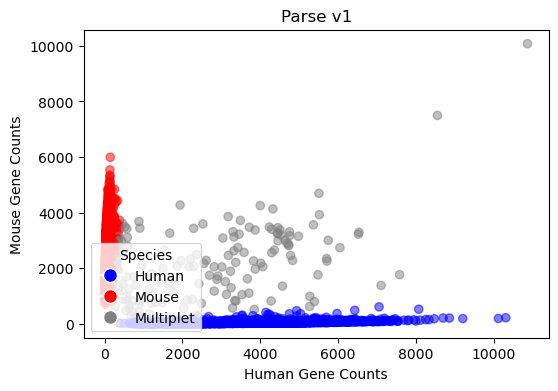

count    5098.000000
mean        0.013479
std         0.007641
min         0.003347
25%         0.009496
50%         0.011675
75%         0.014748
max         0.098255
Name: percent_mouse, dtype: float64
count    5098.000000
mean       47.633189
std        33.363904
min         4.000000
25%        29.000000
50%        41.000000
75%        57.000000
max       611.000000
Name: mm10_gene_count, dtype: float64
90th percentile of mouse counts: 80.0
count    4687.000000
mean        0.024334
std         0.011652
min         0.006333
25%         0.017476
50%         0.021338
75%         0.027108
max         0.099336
Name: percent_human, dtype: float64
count    4687.000000
mean       61.152763
std        37.324312
min         6.000000
25%        38.000000
50%        53.000000
75%        74.000000
max       384.000000
Name: hg38_gene_count, dtype: float64
90th percentile of human counts: 102.0


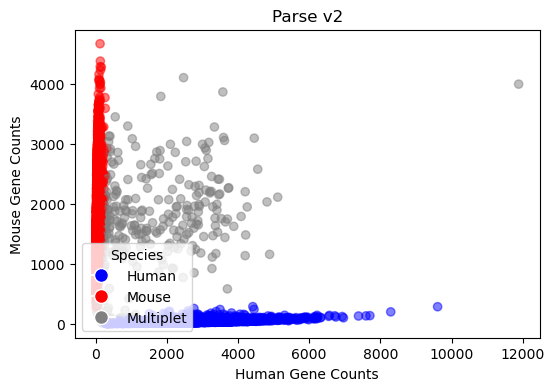

count    6639.000000
mean        0.016586
std         0.008865
min         0.002857
25%         0.012024
50%         0.014625
75%         0.018107
max         0.099880
Name: percent_mouse, dtype: float64
count    6639.000000
mean       42.464980
std        21.597902
min         1.000000
25%        28.000000
50%        39.000000
75%        53.000000
max       287.000000
Name: mm10_gene_count, dtype: float64
90th percentile of mouse counts: 68.0
count    7133.000000
mean        0.027435
std         0.011400
min         0.007053
25%         0.020065
50%         0.024965
75%         0.031636
max         0.099323
Name: percent_human, dtype: float64
count    7133.000000
mean       51.115800
std        26.321283
min         6.000000
25%        33.000000
50%        46.000000
75%        63.000000
max       317.000000
Name: hg38_gene_count, dtype: float64
90th percentile of human counts: 82.0


In [4]:
for metadata, name in zip(parse_metadata, ["v1", "v2"]):
    plt.figure(figsize=(6, 4))

    colors = metadata['species'].map({'hg38': 'blue', 'mm10': 'red', 'multiplet': 'grey'}).to_list()
    plt.scatter(metadata['hg38_gene_count'], metadata['mm10_gene_count'], alpha=0.5, c=colors)
    plt.xlabel('Human Gene Counts')
    plt.ylabel('Mouse Gene Counts')
    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Human', markerfacecolor='blue', markersize=10),
                        plt.Line2D([0], [0], marker='o', color='w', label='Mouse', markerfacecolor='red', markersize=10),
                        plt.Line2D([0], [0], marker='o', color='w', label='Multiplet', markerfacecolor='grey', markersize=10)],
            title='Species', loc='lower left')
    # plt.yscale('log')
    # plt.xscale('log')
    plt.title(f"Parse {name}")
    plt.show()

    for species in ['hg38', 'mm10']:
        cells = metadata[metadata['species'] == species]
        if species == 'hg38':
            print(cells['percent_mouse'].describe())
            print(cells['mm10_gene_count'].describe())
            print("90th percentile of mouse counts:", np.percentile(cells['mm10_gene_count'], 90))
        else:
            print(cells['percent_human'].describe())
            print(cells['hg38_gene_count'].describe())
            print("90th percentile of human counts:", np.percentile(cells['hg38_gene_count'], 90))

In [5]:
for metadata in parse_metadata:
    human_cells = metadata[metadata['species'] == 'hg38']
    print(np.min(human_cells['percent_human']))

0.9017450682852808
0.9001196172248804


In [7]:
data_dir = Path.cwd() / "10x_data"
data_dir.mkdir(exist_ok=True)

h5ad_url = "https://cf.10xgenomics.com/samples/cell-exp/8.0.0/5k_hgmm_3p_nextgem_5k_hgmm_3p_nextgem/5k_hgmm_3p_nextgem_5k_hgmm_3p_nextgem_count_sample_filtered_feature_bc_matrix.h5"
h5ad_path = data_dir / "matrix.h5"
r=requests.get(h5ad_url, allow_redirects=True)
r.raise_for_status()
with open(h5ad_path, 'wb') as f:
    f.write(r.content)

adata = sc.read_10x_h5(h5ad_path)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
adata.obs['human_counts'] = adata[:, adata.var['genome']=='GRCh38'].X.sum(axis=1).A1
adata.obs['mouse_counts'] = adata[:, adata.var['genome']=='GRCm39'].X.sum(axis=1).A1
adata.obs['total_counts'] = adata.obs['human_counts'] + adata.obs['mouse_counts']
adata.obs['species'] = 'multiplet'
adata.obs['percent_human'] = adata.obs['human_counts'] / adata.obs['total_counts']
adata.obs['percent_mouse'] = adata.obs['mouse_counts'] / adata.obs['total_counts']
adata.obs.loc[adata.obs['percent_human'] > 0.90, 'species'] = 'hg38'
adata.obs.loc[adata.obs['percent_mouse'] > 0.90, 'species'] = 'mm10'

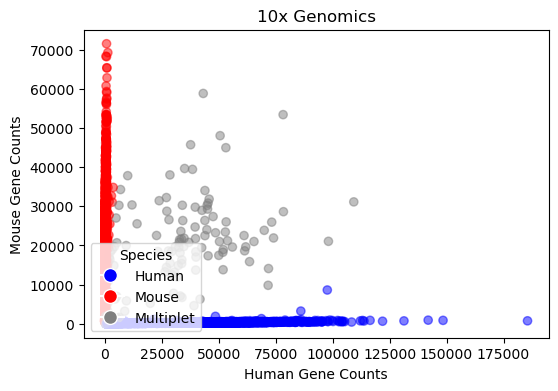

In [11]:
plt.figure(figsize=(6, 4))

colors = adata.obs['species'].map({'hg38': 'blue', 'mm10': 'red', 'multiplet': 'grey'}).to_list()
plt.scatter(adata.obs['human_counts'], adata.obs['mouse_counts'], alpha=0.5, c=colors)
plt.xlabel('Human Gene Counts')
plt.ylabel('Mouse Gene Counts')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Human', markerfacecolor='blue', markersize=10),
                    plt.Line2D([0], [0], marker='o', color='w', label='Mouse', markerfacecolor='red', markersize=10),
                    plt.Line2D([0], [0], marker='o', color='w', label='Multiplet', markerfacecolor='grey', markersize=10)],
        title='Species', loc='lower left')
plt.title("10x Genomics")
# plt.yscale('log')
# plt.xscale('log')

plt.show()

In [10]:
for species in ['hg38', 'mm10']:
    cells = adata.obs[adata.obs['species'] == species]
    if species == 'hg38':
        print(cells['percent_mouse'].describe())
        print(cells['mouse_counts'].describe())
    else:
        print(cells['percent_human'].describe())
        print(cells['human_counts'].describe())

count    2499.000000
mean        0.010316
std         0.013907
min         0.000000
25%         0.005382
50%         0.006285
75%         0.007855
max         0.099556
Name: percent_mouse, dtype: float64
count    2499.000000
mean      259.851135
std       229.970932
min         0.000000
25%       164.500000
50%       240.000000
75%       327.000000
max      8617.000000
Name: mouse_counts, dtype: float64
count    2439.000000
mean        0.016934
std         0.011297
min         0.004926
25%         0.011669
50%         0.013885
75%         0.017334
max         0.099526
Name: percent_human, dtype: float64
count    2439.000000
mean      328.521515
std       217.250290
min         3.000000
25%       223.000000
50%       293.000000
75%       385.000000
max      3682.000000
Name: human_counts, dtype: float64
